In [31]:
import numpy as np
from simulator_fn import *

In [32]:
simulation_time = 1000
neuron_amounts = (0, 0, 0, 0, 0, 12, 6, 2)

adj_matrix, conn_matrix  = np.load(f"./solutions/best_solution-4.npy")

In [33]:
print(adj_matrix)
print(conn_matrix)

[[ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -8. -8.]
 [ 0.  0.  0.  0.  0.  8.  0.  8.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]]
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 3. 4.]
 [0. 0. 0. 0. 0. 4. 0. 3.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


In [34]:
# conn_matrix -= 1
# conn_matrix = np.fmax(conn_matrix, 0)
# conn_matrix[:,:] = 5

In [35]:
t0 = time.time()
# sim, volt = run_simulator(adj_matrix, conn_matrix, simulation_time=simulation_time, neuron_amounts=neuron_amounts, record_volt=False)
sim = run_simulator(adj_matrix, conn_matrix, simulation_time=simulation_time, neuron_amounts=neuron_amounts, record_volt=False)
t1 = time.time()
print(f"time simulator: {t1 - t0}s")

time simulator: 28.706221103668213s


In [36]:
[len(i) for i in sim]

[5494,
 5618,
 6378,
 5181,
 5208,
 5587,
 5814,
 5525,
 2898,
 5917,
 10779,
 6681,
 0,
 2814,
 0,
 2455,
 0,
 1932,
 19815,
 25874]

In [37]:
collapsed_sim = np.asarray(sorted(list(set(sum(sim, start=[])))))
len(collapsed_sim)

117223

In [38]:
pd.DataFrame(collapsed_sim).describe().T

,count,mean,std,min,25%,50%,75%,max
0,117223.0,500.534822,288.489487,0.057,251.0835,500.488,750.457,999.996


In [39]:
bin_size = 0.2
sim_len = len(collapsed_sim)
freq = 0
freq_list = np.empty(len(collapsed_sim))

t0 = time.time()
for idx, act_time in enumerate(collapsed_sim):
    ## Count number of activations in bin 
    # Start with activations before the current time within the bin
    # bin_start = act_time
    # bin_start_idx = idx
    # while bin_start_idx > 0 and act_time - bin_start < bin_size:
    #     bin_start = collapsed_sim[bin_start_idx]
    #     bin_start_idx -= 1

    # Calculate activations after the current time within the bin
    # bin_end = act_time
    # bin_end_idx = idx
    # while bin_end_idx < sim_len and bin_end - act_time < bin_size:
    #     bin_end = collapsed_sim[bin_end_idx]
    #     bin_end_idx += 1

    ## Count number of activations in bin 
    bin_start_idx = np.searchsorted(collapsed_sim, act_time-bin_size, side='left')+1
    bin_start = collapsed_sim[bin_start_idx]

    # bin_end_idx = np.searchsorted(collapsed_sim, act_time+bin_size/2, side='right')-1
    # bin_end = collapsed_sim[bin_end_idx]
    
    # Number of activations in the bin == size of the bin
    # n_activations_in_bin = bin_end_idx - bin_start_idx + 1
    n_activations_in_bin = idx - bin_start_idx + 1

    # Use frequency formula
    if act_time - bin_start > bin_size/2:
        freq_aux = (n_activations_in_bin-1) / (act_time - bin_start)
    else:
        freq_aux = n_activations_in_bin / bin_size
    
    freq += freq_aux
    freq_list[idx] = freq_aux

freq = freq/sim_len
t1 = time.time()
print(f"time freq calculation: {t1 - t0}s")

print(freq)

time freq calculation: 0.30208683013916016s
121.69967733456662


0.01726623614819617

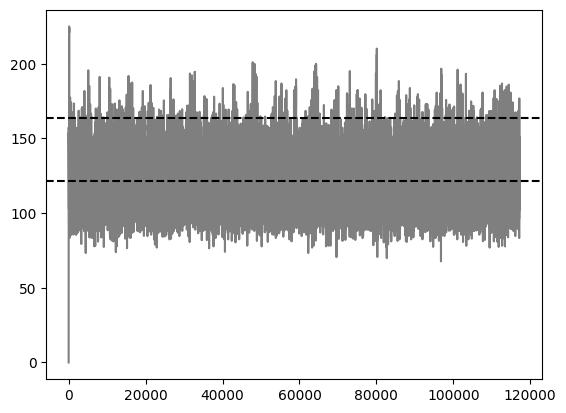

In [41]:
d = 2.5
thresh = freq_list.mean() + d*freq_list.std()

plt.plot(freq_list, color="black", alpha=0.5)
plt.axhline(freq_list.mean(), color="k", ls="--")
plt.axhline(thresh, color="k", ls="--")
np.count_nonzero(freq_list > thresh)/len(freq_list)